# Modeling2_LGBM_prediction — 감성 보조피처 예측

모델링1 `final_aic_features` 19개를 base로 고정하고, 뉴스 감성 4개를 추가한 LGBM 예측 성능을 비교한다.

- **baseline** 19개 vs **+sentiment** 23개
- LGBM default / Optuna tuned 두 설정에서 각각 비교 (튜닝은 baseline·+sentiment 각각 별도 수행)
- Optuna 튜닝은 train 내부 TimeSeriesSplit CV에서만 — test 누수 금지


## 1. 설정 + 데이터

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from IPython.display import display

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_SEED = 42
N_TRIALS = 40
N_SPLITS = 5
EARLY_STOPPING_ROUNDS = 50

cfg = json.load(open("../outputs/modeling2/final_features_v2.json", encoding="utf-8"))
TARGET        = cfg["target"]
SPLIT_DATE    = pd.Timestamp(cfg["split_date"])
base_cols     = cfg["base_features"]
sentiment_all = cfg["sentiment_features"]
model_cols    = cfg["all_features"]
print("base:", len(base_cols), "| sentiment:", sentiment_all, "| split:", SPLIT_DATE.date())


base: 19 | sentiment: ['sent_supply_7d', 'sent_demand_7d', 'sent_geopolitical_7d', 'sent_financial_7d'] | split: 2022-07-20


In [2]:
# 데이터 로드 + merge
sent_df = pd.read_csv("../data/Sentiment_Final/sentiment_avg_7d_final.csv", parse_dates=["date"])
base_df = pd.read_csv("../data/Finance_Final/dataset4_derived_full_with_dummies.csv", parse_dates=["date"])
sent_keep = ["date"] + [c for c in sent_df.columns if c.startswith("sent_")]

df_model = (base_df.merge(sent_df[sent_keep], on="date", how="inner")
                   .sort_values("date").reset_index(drop=True))
df_model = df_model[["date"] + model_cols + [TARGET]].dropna().reset_index(drop=True)
print("merged:", df_model.shape, "|", df_model["date"].min().date(), "~", df_model["date"].max().date())


merged: (4547, 25) | 2008-01-31 ~ 2026-03-13


In [3]:
# train/test 분리
train = df_model[df_model["date"] <  SPLIT_DATE].reset_index(drop=True)
test  = df_model[df_model["date"] >= SPLIT_DATE].reset_index(drop=True)
y_train, y_test = train[TARGET], test[TARGET]

X_train_base, X_test_base = train[base_cols],  test[base_cols]
X_train_sent, X_test_sent = train[model_cols], test[model_cols]
print(f"train n={len(train)} / test n={len(test)}")


train n=3637 / test n=910


## 2. 평가 함수

In [4]:
def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_pred != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))

def regression_metrics(y_true, y_pred):
    return {
        "RMSE":   float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":    float(mean_absolute_error(y_true, y_pred)),
        "R2":     float(r2_score(y_true, y_pred)),
        "DirAcc": directional_accuracy(y_true, y_pred),
    }

def model_row(name, y_true, y_pred, n_vars):
    return {"model": name, "n_vars": n_vars, **regression_metrics(y_true, y_pred)}


## 3. 기준선 — naive & OLS

In [5]:
pred_naive_zero = np.zeros(len(y_test))
pred_naive_lag1 = df_model[TARGET].shift(1)[df_model["date"] >= SPLIT_DATE].fillna(0).values

# OLS (참고용 — baseline / +sentiment)
def ols_pred(Xtr, Xte):
    m = sm.OLS(y_train, sm.add_constant(Xtr, has_constant="add")).fit()
    return m.predict(sm.add_constant(Xte, has_constant="add")).values

pred_ols_base = ols_pred(X_train_base, X_test_base)
pred_ols_sent = ols_pred(X_train_sent, X_test_sent)

rows_base = [
    model_row("naive_zero",      y_test, pred_naive_zero, 0),
    model_row("naive_lag1",      y_test, pred_naive_lag1, 1),
    model_row("OLS baseline",    y_test, pred_ols_base, len(base_cols)),
    model_row("OLS +sentiment",  y_test, pred_ols_sent, len(model_cols)),
]
display(pd.DataFrame(rows_base).round(5))


,model,n_vars,RMSE,MAE,R2,DirAcc
0,naive_zero,0,1.70028,1.25826,-0.00005,NaN
1,naive_lag1,1,2.32838,1.77543,-0.87537,0.50220
2,OLS baseline,19,1.75830,1.29644,-0.06946,0.49560
3,OLS +sentiment,23,1.75888,1.29661,-0.07016,0.49011


## 4. LGBM default — baseline vs +sentiment

In [6]:
def fit_lgbm_default(Xtr, Xte):
    m = LGBMRegressor(random_state=RANDOM_SEED, verbosity=-1)
    m.fit(Xtr, y_train)
    return m, m.predict(Xte)

lgbm_def_base, pred_def_base = fit_lgbm_default(X_train_base, X_test_base)
lgbm_def_sent, pred_def_sent = fit_lgbm_default(X_train_sent, X_test_sent)

display(pd.DataFrame([
    model_row("LGBM default baseline",   y_test, pred_def_base, len(base_cols)),
    model_row("LGBM default +sentiment", y_test, pred_def_sent, len(model_cols)),
]).round(5))


,model,n_vars,RMSE,MAE,R2,DirAcc
0,LGBM default baseline,19,1.85822,1.35035,-0.19447,0.52747
1,LGBM default +sentiment,23,1.83623,1.35278,-0.16637,0.48571


## 5. Optuna 하이퍼파라미터 튜닝

baseline·+sentiment **각각** train 내부 TimeSeriesSplit(5) CV RMSE를 최소화하도록 따로 튜닝한다.
(같은 파라미터를 공유하면 한쪽 피처셋에 유리하게 편향될 수 있어 분리)

In [7]:
def make_objective(X):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
            "max_depth":         trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
            "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 1.0),
            "reg_lambda":        trial.suggest_float("reg_lambda", 0.0, 1.0),
            "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        }
        tscv = TimeSeriesSplit(n_splits=N_SPLITS)
        rmses = []
        for tr_idx, va_idx in tscv.split(X):
            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            m = LGBMRegressor(**params, random_state=RANDOM_SEED, verbosity=-1)
            m.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="rmse",
                  callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), log_evaluation(0)])
            rmses.append(float(np.sqrt(mean_squared_error(yva, m.predict(Xva)))))
        return float(np.mean(rmses))
    return objective

def run_study(X, label):
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(make_objective(X), n_trials=N_TRIALS, show_progress_bar=False)
    print(f"[{label}] best CV RMSE = {study.best_value:.5f}")
    return study

study_base = run_study(X_train_base, "baseline")
study_sent = run_study(X_train_sent, "+sentiment")


[baseline] best CV RMSE = 1.79035


[+sentiment] best CV RMSE = 1.79170


## 6. 최적 파라미터로 최종 학습

In [8]:
def fit_tuned(params, Xtr, Xte):
    m = LGBMRegressor(**params, random_state=RANDOM_SEED, verbosity=-1)
    m.fit(Xtr, y_train)
    return m, m.predict(Xte)

lgbm_tuned_base, pred_tuned_base = fit_tuned(study_base.best_params, X_train_base, X_test_base)
lgbm_tuned_sent, pred_tuned_sent = fit_tuned(study_sent.best_params, X_train_sent, X_test_sent)

display(pd.DataFrame([
    model_row("LGBM tuned baseline",   y_test, pred_tuned_base, len(base_cols)),
    model_row("LGBM tuned +sentiment", y_test, pred_tuned_sent, len(model_cols)),
]).round(5))


,model,n_vars,RMSE,MAE,R2,DirAcc
0,LGBM tuned baseline,19,2.04371,1.47085,-0.44484,0.50769
1,LGBM tuned +sentiment,23,1.97981,1.38375,-0.35590,0.50769


## 7. 모델 비교 표

In [9]:
compare = pd.DataFrame(rows_base + [
    model_row("LGBM default baseline",   y_test, pred_def_base,   len(base_cols)),
    model_row("LGBM default +sentiment", y_test, pred_def_sent,   len(model_cols)),
    model_row("LGBM tuned baseline",     y_test, pred_tuned_base, len(base_cols)),
    model_row("LGBM tuned +sentiment",   y_test, pred_tuned_sent, len(model_cols)),
]).round(5)
display(compare.sort_values("RMSE").reset_index(drop=True))

print("\n[감성 보조피처 추가 효과 — 동일 설정 내 baseline 대비]")
for cfg_name, b, s in [
    ("LGBM default", pred_def_base,   pred_def_sent),
    ("LGBM tuned",   pred_tuned_base, pred_tuned_sent),
]:
    rb, rs = regression_metrics(y_test, b), regression_metrics(y_test, s)
    print(f"  {cfg_name:13s} RMSE {rb['RMSE']:.5f} -> {rs['RMSE']:.5f} ({rs['RMSE']-rb['RMSE']:+.5f}) | "
          f"DirAcc {rb['DirAcc']:.4f} -> {rs['DirAcc']:.4f} ({rs['DirAcc']-rb['DirAcc']:+.4f})")


,model,n_vars,RMSE,MAE,R2,DirAcc
0,naive_zero,0,1.70028,1.25826,-0.00005,NaN
1,OLS baseline,19,1.75830,1.29644,-0.06946,0.49560
2,OLS +sentiment,23,1.75888,1.29661,-0.07016,0.49011
3,LGBM default +sentiment,23,1.83623,1.35278,-0.16637,0.48571
4,LGBM default baseline,19,1.85822,1.35035,-0.19447,0.52747
5,LGBM tuned +sentiment,23,1.97981,1.38375,-0.35590,0.50769
6,LGBM tuned baseline,19,2.04371,1.47085,-0.44484,0.50769
7,naive_lag1,1,2.32838,1.77543,-0.87537,0.50220



[감성 보조피처 추가 효과 — 동일 설정 내 baseline 대비]
  LGBM default  RMSE 1.85822 -> 1.83623 (-0.02199) | DirAcc 0.5275 -> 0.4857 (-0.0418)
  LGBM tuned    RMSE 2.04371 -> 1.97981 (-0.06390) | DirAcc 0.5077 -> 0.5077 (+0.0000)


## 8. TimeSeriesSplit CV — +sentiment tuned 안정성

In [10]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_rows = []
for k, (tr_idx, va_idx) in enumerate(tscv.split(X_train_sent), 1):
    Xtr, Xva = X_train_sent.iloc[tr_idx], X_train_sent.iloc[va_idx]
    ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    m = LGBMRegressor(**study_sent.best_params, random_state=RANDOM_SEED, verbosity=-1)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="rmse",
          callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), log_evaluation(0)])
    cv_rows.append({"fold": k, **regression_metrics(yva, m.predict(Xva))})
cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(5))
summary = cv_df[["RMSE","MAE","R2","DirAcc"]].agg(["mean","std"]).T
summary["mean ± std"] = summary.apply(lambda r: f"{r['mean']:.5f} ± {r['std']:.5f}", axis=1)
print("fold 평균 ± 표준편차:")
display(summary[["mean ± std"]])


,fold,RMSE,MAE,R2,DirAcc
0,1,1.70949,1.27531,0.00220,0.47855
1,2,1.31563,0.99148,-0.00103,0.51155
2,3,1.11048,0.85321,-0.00010,0.50990
3,4,1.17848,0.83802,0.00069,0.45875
4,5,3.64443,1.62254,0.00452,0.47855


fold 평균 ± 표준편차:


,mean ± std
RMSE,1.79170 ± 1.06138
MAE,1.11611 ± 0.33309
R2,0.00125 ± 0.00217
DirAcc,0.48746 ± 0.02273


## 9. 예측 시각화

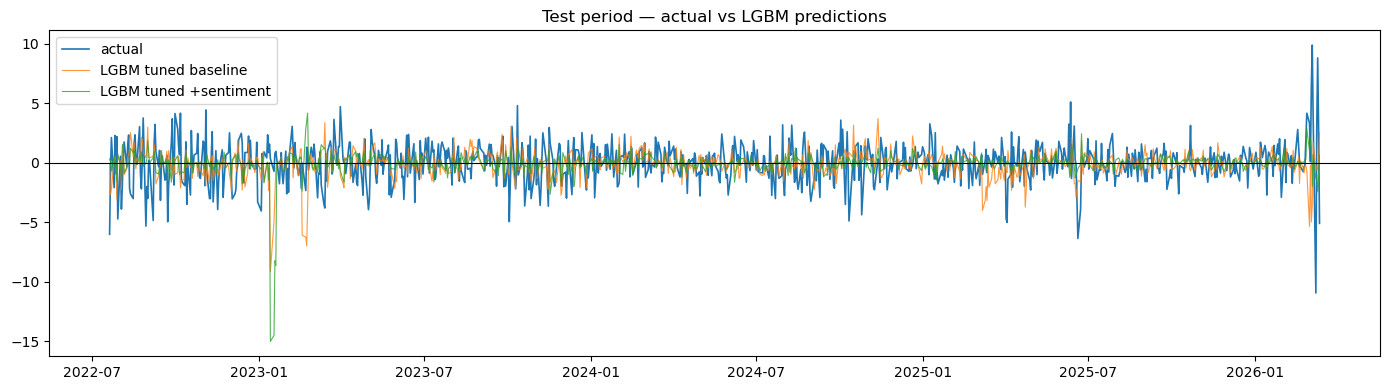

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(test["date"], y_test.values,       label="actual",            lw=1.2)
plt.plot(test["date"], pred_tuned_base,      label="LGBM tuned baseline",   lw=0.8, alpha=0.8)
plt.plot(test["date"], pred_tuned_sent,      label="LGBM tuned +sentiment", lw=0.8, alpha=0.8)
plt.axhline(0, lw=0.8, color="black")
plt.title("Test period — actual vs LGBM predictions")
plt.legend(); plt.tight_layout(); plt.show()


## 10. 저장

In [12]:
OUT_DIR = Path("../outputs/modeling2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

compare.to_csv(OUT_DIR / "lgbm2_prediction_compare.csv", index=False)

best_payload = {
    "n_trials": N_TRIALS, "n_splits_cv": N_SPLITS, "random_state": RANDOM_SEED,
    "baseline":   {"best_cv_rmse": study_base.best_value, "best_params": study_base.best_params},
    "+sentiment": {"best_cv_rmse": study_sent.best_value, "best_params": study_sent.best_params},
}
with open(OUT_DIR / "lgbm2_best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_payload, f, ensure_ascii=False, indent=2)

pred_test_df = pd.DataFrame({
    "date": test["date"], "actual": y_test.values,
    "naive_lag1": pred_naive_lag1,
    "lgbm_tuned_baseline":   pred_tuned_base,
    "lgbm_tuned_sentiment":  pred_tuned_sent,
})
pred_test_df.to_csv(OUT_DIR / "lgbm2_pred_test.csv", index=False)

print("저장 완료:")
for fn in ["lgbm2_prediction_compare.csv", "lgbm2_best_params.json", "lgbm2_pred_test.csv"]:
    print(" -", OUT_DIR / fn)


저장 완료:
 - ../outputs/modeling2/lgbm2_prediction_compare.csv
 - ../outputs/modeling2/lgbm2_best_params.json
 - ../outputs/modeling2/lgbm2_pred_test.csv
